# 08 · Evaluation, Deployment & Monitoring
**Process-model step:** *Interpret, evaluate and deploy the model* — post-processing (Fraud Analytics ch. 6–7) · **AML concept:** model risk, scenario governance, re-tuning triggers · **Statistics:** bootstrap confidence intervals & traffic lights, PSI/SSI, binomial calibration test, control charts, paired bootstrap for champion–challenger, Monte-Carlo loss simulation

The **analytical model life cycle** (Fig. 6.1): development → testing → staging → production → retirement. This notebook walks through it for the fraud model from notebook 06 and for the AML scenario thresholds from notebook 04.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib, json, subprocess, sys, time, shutil, warnings
warnings.filterwarnings("ignore")
from scipy import stats
from sklearn.metrics import average_precision_score, roc_auc_score
import amlkit as ak

pd.set_option("display.float_format", "{:,.3f}".format); pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
DEPLOY = ak.ROOT / "deploy"; DEPLOY.mkdir(exist_ok=True)

champ = joblib.load(ak.ROOT / "models" / "fraud_champion.joblib"); chall = joblib.load(ak.ROOT / "models" / "fraud_challenger.joblib")
CH, CG, FC, FG = champ["model"], chall["model"], champ["features"], chall["features"]
scored = pd.read_pickle(ak.PROC / "fraud_scored.pkl")
train, test = scored[scored.split == "train"], scored[scored.split == "test"].copy()
print(f"champion: {champ['name']} | challenger: {chall['name']} | train {len(train):,} txns | test {len(test):,} txns ({int(test.is_fraud.sum())} frauds)")

champion: fraud_champion_logit | challenger: fraud_challenger_hgb | train 59,029 txns | test 25,434 txns (140 frauds)


## 1 · Model testing — accuracy *with uncertainty*
Fraud Analytics Table 1.4 lists what a good model needs (statistical accuracy, interpretability, operational efficiency, economic cost, regulatory compliance). Start with accuracy on the out-of-time test set, reported with **customer-cluster bootstrap** intervals (transactions of one customer are not independent).

In [2]:
def metrics(y, p, share=0.01):
    o = np.argsort(-p); k = max(1, int(share * len(y)))
    return dict(AUC=roc_auc_score(y, p), AP=average_precision_score(y, p), recall_at_1pct=y[o[:k]].sum() / y.sum())

def cluster_boot(df, pcol, B=200, seed=0):
    r = np.random.default_rng(seed); groups = df.groupby("customer_id").indices
    keys = np.array(list(groups)); y, p = df.is_fraud.values, df[pcol].values; out = []
    for _ in range(B):
        idx = np.concatenate([groups[k] for k in r.choice(keys, len(keys))])
        if y[idx].sum(): out.append(metrics(y[idx], p[idx]))
    return pd.DataFrame(out)

rows = {}
for name, col in [("champion (logistic)", "p_champion"), ("challenger (boosting)", "p_challenger")]:
    b = cluster_boot(test, col); pt = metrics(test.is_fraud.values, test[col].values)
    rows[name] = {f"{m}": f"{pt[m]:.3f}  [{b[m].quantile(.025):.3f}, {b[m].quantile(.975):.3f}]" for m in pt}
pd.DataFrame(rows).T

,AUC,AP,recall_at_1pct
champion (logistic),"0.946 [0.924, 0.970]","0.711 [0.602, 0.789]","0.721 [0.641, 0.806]"
challenger (boosting),"0.948 [0.922, 0.971]","0.715 [0.601, 0.796]","0.743 [0.661, 0.824]"


## 2 · Selecting the sample to investigate (ch. 6)
Analysts can work only **K alerts per day**. Which ranking rule and mix is best? Compare (i) top-K by score, (ii) top-K by *expected loss* (score × amount), (iii) 80 % top-score + **20 % random** exploration. The random slice costs some fraud found today but produces **unbiased labels** for retraining and for estimating false negatives (notebooks 05–06).

In [3]:
K = 4
def run_capacity(df, rank, rand_share=0.0, seed=0):
    r = np.random.default_rng(seed); tot = dict(frauds=0, fraud_value=0.0, random_reviews=0, random_frauds=0)
    for _, g in df.groupby("day"):
        kk = min(K, len(g)); n_r = int(round(rand_share * kk)); top = g.loc[rank(g).sort_values(ascending=False).index[:kk - n_r]]
        rnd = g.drop(top.index).sample(n_r, random_state=int(r.integers(1e9))) if n_r else g.iloc[0:0]
        sel = pd.concat([top, rnd])
        tot["frauds"] += sel.is_fraud.sum(); tot["fraud_value"] += (sel.is_fraud * sel.amount_usd).sum()
        tot["random_reviews"] += len(rnd); tot["random_frauds"] += rnd.is_fraud.sum()
    return tot
strategies = {"top-K by score": (lambda g: g.p_champion, 0.0), "top-K by score x amount": (lambda g: g.p_champion * g.amount_usd, 0.0),
              "80% top score + 20% random": (lambda g: g.p_champion, 0.2)}
cap = pd.DataFrame({k: run_capacity(test, f, s) for k, (f, s) in strategies.items()}).T
cap["share of all fraud value"] = cap.fraud_value / (test.is_fraud * test.amount_usd).sum()
cap["share of all frauds"] = cap.frauds / test.is_fraud.sum(); cap

,frauds,fraud_value,random_reviews,random_frauds,share of all fraud value,share of all frauds
top-K by score,68.000,"15,234.320",0.000,0.000,0.526,0.486
top-K by score x amount,66.000,"19,163.460",0.000,0.000,0.661,0.471
80% top score + 20% random,56.000,"12,697.690",110.000,0.000,0.438,0.400


## 3 · Model representation: traffic lights and decision tables
Turn scores into actions analysts and regulators understand. Thresholds come from **training-score quantiles** (so they are fixed *before* looking at test data) and are stored in a policy file that the batch job reads.

In [4]:
policy = dict(red=float(np.quantile(train.p_champion, .995)), amber=float(np.quantile(train.p_champion, .98)),
              rule="RED = top 0.5% of training scores, AMBER = next 1.5%", model=champ["name"])
json.dump(policy, open(DEPLOY / "policy.json", "w"), indent=2)
test["light"] = np.where(test.p_champion >= policy["red"], "RED", np.where(test.p_champion >= policy["amber"], "AMBER", "GREEN"))
tl = test.groupby("light").agg(txns=("txn_id", "size"), frauds=("is_fraud", "sum"), fraud_value=("amount_usd", lambda s: (s * test.loc[s.index, "is_fraud"]).sum()))
tl["share of txns"] = tl.txns / tl.txns.sum(); tl["precision"] = tl.frauds / tl.txns; tl["share of frauds"] = tl.frauds / tl.frauds.sum()
tl = tl.loc[["RED", "AMBER", "GREEN"]]; display(tl)
pd.DataFrame({"light": ["RED", "AMBER", "GREEN"], "action": ["decline / step-up authentication now; analyst queue priority 1", "allow with SMS challenge; analyst queue priority 2", "allow"],
              "SLA": ["< 15 min", "< 4 h", "-"]})

,txns,frauds,fraud_value,share of txns,precision,share of frauds
light,,,,,,
RED,140,94,"21,764.480",0.006,0.671,0.671
AMBER,343,13,"3,040.840",0.013,0.038,0.093
GREEN,24951,33,"4,179.280",0.981,0.001,0.236


,light,action,SLA
0,RED,decline / step-up authentication now; analyst ...,< 15 min
1,AMBER,allow with SMS challenge; analyst queue priori...,< 4 h
2,GREEN,allow,-


## 4 · Deployment package — testing what actually ships
### 4.1 Training / serving parity
The most common production failure is **skew** between the features used in training and those computed live. Re-compute the features with the *deployment function* `ak.card_features` from raw cleaned data and compare with what the model was trained on:

In [5]:
txn = pd.read_pickle(ak.PROC / "txn_clean.pkl")
serve = ak.card_features(txn[txn.channel == "card_online"])
chk = test[["txn_id"] + FC].merge(serve[["txn_id"] + FC], on="txn_id", suffixes=("_train", "_serve"))
diff = pd.Series({f: np.abs(chk[f + "_train"] - chk[f + "_serve"]).max() for f in FC}); print("max |train - serve| per feature:"); print(diff.to_string())
assert diff.max() < 1e-9, "training/serving skew!"

max |train - serve| per feature:
log_amt              0.000
hour                 0.000
night                0.000
foreign              0.000
new_device           0.000
amt_z                0.000
log_hrs_since_prev   0.000
n_prev_1h            0.000
n_prev_24h           0.000


### 4.2 Latency and robustness (model testing stage)
A card authorisation must be scored in milliseconds (the book's example: < 5 s incl. everything). Also verify behaviour with **missing or extreme inputs** — dummy fraud cases should still be flagged, garbage must not crash the scorer.

In [6]:
x1 = test[FC].iloc[[0]]
def latency(m, cols, n=300):
    t = time.perf_counter()
    for _ in range(n): m.predict_proba(x1[cols])
    return (time.perf_counter() - t) / n * 1000
lat = pd.Series({"champion (logistic pipeline)": latency(CH, FC), "challenger (boosting)": latency(CG, FG)}, name="ms per single-row score"); print(lat.round(2).to_string())

edge = pd.DataFrame([test[FC].median().to_dict(),                                           # typical
                     {**test[FC].median().to_dict(), "log_amt": np.nan},                    # missing
                     {**test[FC].median().to_dict(), "log_amt": 30.0, "n_prev_1h": 500},    # absurd
                     dict(log_amt=6.0, hour=3, night=1, foreign=1, new_device=1, amt_z=2.5, log_hrs_since_prev=0.1, n_prev_1h=4, n_prev_24h=6)])   # dummy fraud case
try: CH.predict_proba(edge[FC])
except Exception as ex: print("naive scorer fails on garbage:", type(ex).__name__)

lo, hi, med = train[FC].quantile(0.001), train[FC].quantile(0.999), train[FC].median()
def safe_score(model, cols, X):
    Z = X[cols].replace([np.inf, -np.inf], np.nan).fillna(med[cols]).clip(lower=lo[cols], upper=hi[cols], axis=1)
    return model.predict_proba(Z)[:, 1]
edge["safe_score"] = safe_score(CH, FC, edge); edge.assign(case=["typical", "missing amount", "absurd values", "dummy fraud pattern"])[["case", "safe_score"]]

champion (logistic pipeline)   0.920
challenger (boosting)          1.570
naive scorer fails on garbage: ValueError


,case,safe_score
0,typical,0.000
1,missing amount,0.000
2,absurd values,0.800
3,dummy fraud pattern,1.000


### 4.3 Run the deployed batch job
The scheduled job `deploy/score_batch.py` reads raw extracts (with history for velocity features), applies the *same* cleaning and features, scores, assigns lights and reason codes, and exits non-zero on a data-contract violation. Run it on the last ten days as if they were tonight's batch, and reconcile with the notebook scores:

In [7]:
raw = pd.read_csv(ak.RAW / "transactions.csv.gz", parse_dates=["ts"])
cut = ak.START + pd.Timedelta(days=355)
tmp = DEPLOY / "_tmp"; tmp.mkdir(exist_ok=True)
raw[raw.ts < cut].to_csv(tmp / "history.csv.gz", index=False); raw[raw.ts >= cut].to_csv(tmp / "batch.csv.gz", index=False)
r = subprocess.run([sys.executable, str(DEPLOY / "score_batch.py"), "--batch", str(tmp / "batch.csv.gz"), "--history", str(tmp / "history.csv.gz"),
                    "--out", str(DEPLOY / "demo_scored.csv")], capture_output=True, text=True, cwd=ak.ROOT)
print("exit code", r.returncode, "|", r.stdout.strip(), r.stderr[-300:])
out = pd.read_csv(DEPLOY / "demo_scored.csv")
rec = out.merge(test[["txn_id", "p_champion"]], on="txn_id"); print(f"reconciliation with notebook scores: {len(rec):,} rows, max |diff| = {np.abs(rec.score - rec.p_champion).max():.2e}")
shutil.rmtree(tmp); out.head(5)

exit code 0 | {"model": "fraud_champion_logit", "scored": 2226, "red": 8, "amber": 40, "seconds": 1.98} 
reconciliation with notebook scores: 2,226 rows, max |diff| = 9.99e-17


,txn_id,customer_id,ts,amount_usd,score,light,reasons
0,804947,2067,2025-12-24 15:12:06,257.310,0.955,RED,"n_prev_1h, n_prev_24h, foreign"
1,803368,128,2025-12-23 22:00:00,75.230,0.439,RED,"new_device, n_prev_24h, foreign"
2,805692,2690,2025-12-25 01:22:31,288.690,0.307,RED,"new_device, foreign, night"
3,802490,3381,2025-12-23 13:48:32,169.690,0.260,RED,"n_prev_1h, n_prev_24h, foreign"
4,821433,146,2025-12-31 23:42:32,144.150,0.161,RED,"new_device, n_prev_24h, night"


### 4.4 Deploying *scenario thresholds*
AML thresholds are deployed as **configuration under change control**, not code: a versioned file with the parameters, the evidence, the residual risk and the approvals. (The values below come from notebook 04's balanced per-segment set.)

In [8]:
kyc = pd.read_pickle(ak.PROC / "kyc_clean.pkl"); truth = ak.load_truth(); n = len(kyc); seg_of = kyc.set_index("customer_id").segment
PROD = dict(min_single=2500, min_count=3, min_agg=10_000, lookback=5, cooldown=30)
seg_cfg = {"retail_salaried": dict(min_single=1000, min_count=3, min_agg=5000), "retail_self_employed": dict(min_single=1000, min_count=3, min_agg=5000),
           "small_business": dict(min_single=1500, min_count=4, min_agg=12000), "cash_intensive": dict(min_single=1500, min_count=5, min_agg=20000),
           "corporate": dict(min_single=2500, min_count=3, min_agg=15000)}
prod_alerts = ak.simulate_dispositions(ak.run_scenario(txn, n, **PROD), truth)
parts = [ak.run_scenario(txn[txn.customer_id.isin(seg_of.index[seg_of == s])], n, **{**PROD, **p}) for s, p in seg_cfg.items()]
new_alerts = ak.simulate_dispositions(pd.concat(parts, ignore_index=True).assign(alert_id=lambda d: np.arange(1, len(d) + 1)), truth)
cfg = dict(scenario="cash_structuring_5d", version="2.0-proposed", status="PENDING APPROVAL", prepared=str(pd.Timestamp.now().date()),
           parameters_by_segment=seg_cfg, parameters_current=PROD,
           evidence=dict(backtest_period="2025-01-01..2025-12-31", alerts_current=len(prod_alerts), alerts_proposed=len(new_alerts),
                         str_alerts_current=int(prod_alerts.str_filed.sum()), str_alerts_proposed=int(new_alerts.str_filed.sum()),
                         notebook="04_aml_threshold_tuning_workflow, 05_threshold_tuning_statistical_critique"),
           residual_risk="below-the-line activity is estimated by random sampling of non-alerted customers (see notebook 05, E7)",
           controls=dict(next_review_months=6, quarterly_fn_sample_size=300, safety_blanket_rules_retained=True),
           approvals=dict(model_risk=None, mlro=None, head_of_compliance=None))
json.dump(cfg, open(DEPLOY / "scenario_thresholds_v2.json", "w"), indent=2); print(json.dumps(cfg["evidence"], indent=1))

{
 "backtest_period": "2025-01-01..2025-12-31",
 "alerts_current": 1255,
 "alerts_proposed": 725,
 "str_alerts_current": 271,
 "str_alerts_proposed": 270,
 "notebook": "04_aml_threshold_tuning_workflow, 05_threshold_tuning_statistical_critique"
}


## 5 · Backtesting and monitoring (ch. 6)
Fraudsters adapt, so the relationship between features and fraud changes: **concept drift**. The book proposes three backtests: **data stability** (SSI/PSI), **model stability** (performance with a bootstrap traffic light) and **calibration** (binomial test). To see them react, we *simulate* a drift in the last window: 70 % of new fraud now evades the obvious tells (daytime, domestic, known device).

In [9]:
W = {"W1 (d255-284)": (255, 284), "W2 (d285-314)": (285, 314), "W3 (d315-344)": (315, 344), "W4 (d345-364) EVASION": (345, 364)}
wins = {k: test[(test.day >= a) & (test.day <= b)].copy() for k, (a, b) in W.items()}
rng = np.random.default_rng(0); w4 = wins["W4 (d345-364) EVASION"]
ev = (w4.is_fraud.values == 1) & (rng.random(len(w4)) < 0.7)
for col in ("night", "foreign", "new_device"): w4.loc[ev, col] = 0
w4["p_champion"] = CH.predict_proba(w4[FC])[:, 1]
print({k: (len(v), int(v.is_fraud.sum())) for k, v in wins.items()})

{'W1 (d255-284)': (6912, 39), 'W2 (d285-314)': (7050, 35), 'W3 (d315-344)': (6972, 44), 'W4 (d345-364) EVASION': (4500, 22)}


### 5.1 Data stability: SSI / PSI  (thresholds: < 0.10 stable · 0.10–0.25 watch · > 0.25 unstable)

In [10]:
light = lambda v: "GREEN" if v < 0.10 else ("AMBER" if v < 0.25 else "RED")
rows = []
prev = train
for k, w in wins.items():
    rows.append({"window": k, "PSI score vs training": ak.psi(train.p_champion, w.p_champion), "PSI score vs previous": ak.psi(prev.p_champion, w.p_champion),
                 **{f"PSI {f}": ak.psi(train[f], w[f]) for f in ["log_amt", "amt_z", "n_prev_1h"]}}); prev = w
psi_tab = pd.DataFrame(rows).set_index("window"); display(psi_tab)
print("lights (score PSI vs training):", psi_tab["PSI score vs training"].map(light).to_dict())

,PSI score vs training,PSI score vs previous,PSI log_amt,PSI amt_z,PSI n_prev_1h
window,,,,,
W1 (d255-284),0.001,0.001,0.002,0.056,0.000
W2 (d285-314),0.002,0.003,0.002,0.055,0.000
W3 (d315-344),0.001,0.003,0.001,0.054,0.000
W4 (d345-364) EVASION,0.003,0.004,0.001,0.069,0.000


lights (score PSI vs training): {'W1 (d255-284)': 'GREEN', 'W2 (d285-314)': 'GREEN', 'W3 (d315-344)': 'GREEN', 'W4 (d345-364) EVASION': 'GREEN'}


**Population PSI stays green even in the drifted window.** Fraud is < 1 % of the population, so a change in *how fraudsters behave* barely moves the overall score distribution. Data-stability checks catch changes in the *customer base or data feed*; they cannot see concept drift among the rare positives. Hence the next two backtests, which use (delayed) fraud labels.

### 5.2 Model stability: performance with a bootstrap traffic light
Compare each window's average precision with the reference window W1 by bootstrapping the difference; green if not significantly worse, amber at 95 %, red at 99 % (the bootstrap traffic-light procedure of ch. 6).

In [11]:
def boot_ap(df, col, B=500, seed=0):
    r = np.random.default_rng(seed); y, p = df.is_fraud.values, df[col].values; out = []
    while len(out) < B:
        i = r.integers(0, len(y), len(y))
        if y[i].sum(): out.append(average_precision_score(y[i], p[i]))
    return np.array(out)

ref_key = list(wins)[0]; ref_b = boot_ap(wins[ref_key], "p_champion")
rows = []
for k, w in wins.items():
    b = boot_ap(w, "p_champion", seed=1); d = ref_b - b; p_deg = (d <= 0).mean()
    rows.append({"window": k, "frauds": int(w.is_fraud.sum()), "AP": average_precision_score(w.is_fraud, w.p_champion),
                 "AP drop vs W1 (mean)": d.mean(), "p(no degradation)": p_deg,
                 "traffic light": "-" if k == ref_key else ("RED" if p_deg < 0.01 else ("AMBER" if p_deg < 0.05 else "GREEN"))})
perf = pd.DataFrame(rows).set_index("window"); perf

,frauds,AP,AP drop vs W1 (mean),p(no degradation),traffic light
window,,,,,
W1 (d255-284),39,0.746,0.003,0.474,-
W2 (d285-314),35,0.665,0.082,0.224,GREEN
W3 (d315-344),44,0.818,-0.073,0.780,GREEN
W4 (d345-364) EVASION,22,0.182,0.563,0.000,RED


### 5.3 Calibration backtest: binomial test per score band
If the model says 4.7 % of transactions in a band are fraud but 12 % are, risk is **under-estimated**. One-sided binomial test (observed > predicted), bands defined from *training* score quantiles.

In [12]:
edges = np.quantile(train.p_champion, [0, .5, .9, .98, .995, 1]); edges[0], edges[-1] = -np.inf, np.inf
rows = []
for k, w in wins.items():
    band = pd.cut(w.p_champion, edges, labels=["B1 (lowest 50%)", "B2 (50-90%)", "B3 (90-98%)", "B4 (98-99.5%)", "B5 (top 0.5%)"])
    for b, g in w.groupby(band, observed=True):
        pred = g.p_champion.mean(); kf = int(g.is_fraud.sum())
        rows.append({"window": k, "band": b, "n": len(g), "predicted rate": pred, "observed rate": kf / len(g), "frauds": kf,
                     "p-value (under-estimated)": stats.binomtest(kf, len(g), min(max(pred, 1e-9), 1), alternative="greater").pvalue})
cal = pd.DataFrame(rows); cal["light"] = np.where(cal["p-value (under-estimated)"] < .01, "RED", np.where(cal["p-value (under-estimated)"] < .05, "AMBER", "GREEN"))
print(cal.pivot(index="band", columns="window", values="light").to_string())
cal[cal.window.str.startswith("W4")]

window          W1 (d255-284) W2 (d285-314) W3 (d315-344) W4 (d345-364) EVASION
band                                                                           
B1 (lowest 50%)         GREEN         GREEN         GREEN                   RED
B2 (50-90%)             GREEN         GREEN         GREEN                   RED
B3 (90-98%)             GREEN         GREEN         GREEN                 GREEN
B4 (98-99.5%)           GREEN         GREEN         GREEN                 GREEN
B5 (top 0.5%)           GREEN         GREEN         GREEN                 GREEN


,window,band,n,predicted rate,observed rate,frauds,p-value (under-estimated),light
15,W4 (d345-364) EVASION,B1 (lowest 50%),2293,0.000,0.002,5,0.000,RED
16,W4 (d345-364) EVASION,B2 (50-90%),1775,0.001,0.005,9,0.000,RED
17,W4 (d345-364) EVASION,B3 (90-98%),358,0.006,0.008,3,0.395,GREEN
18,W4 (d345-364) EVASION,B4 (98-99.5%),59,0.044,0.000,0,1.000,GREEN
19,W4 (d345-364) EVASION,B5 (top 0.5%),15,0.408,0.333,5,0.800,GREEN


With 5 bands × 4 windows we run 20 tests: expect the odd false amber (multiple comparisons again). A **red** in several bands of the same window, together with a red performance light, is what triggers action.

### 5.4 Alert monitoring for the AML scenario
Control charts on monthly alert **volume** (Poisson *u-chart*) and **productivity** (binomial *p-chart*), plus PSI of the threshold-variable distribution across half-years.

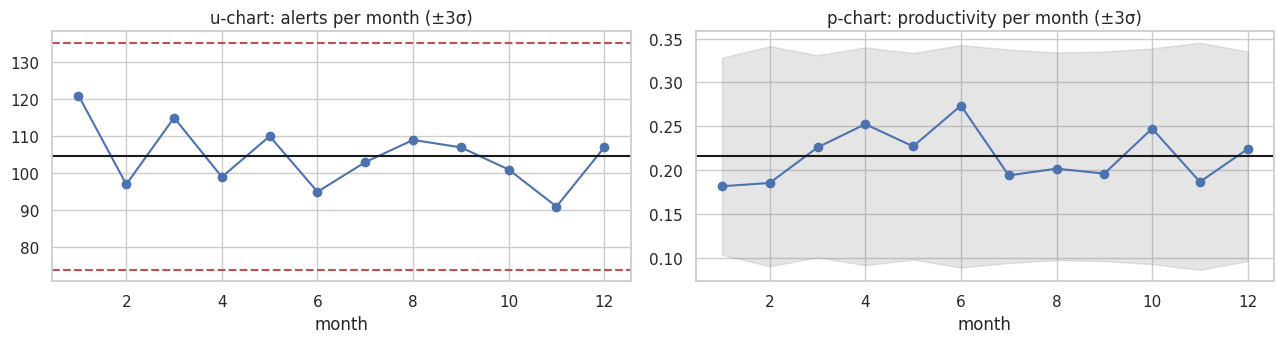

PSI of alert aggregate distribution H1 vs H2 = 0.032  ->  GREEN
months outside control limits (productivity): []


In [13]:
m = prod_alerts.assign(month=prod_alerts.alert_date.dt.month).groupby("month").agg(alerts=("alert_id", "size"), STR=("str_filed", "sum"))
m["prod"] = m.STR / m.alerts; pbar = m.STR.sum() / m.alerts.sum(); ubar = m.alerts.mean()
m["p_lo"] = pbar - 3 * np.sqrt(pbar * (1 - pbar) / m.alerts); m["p_hi"] = pbar + 3 * np.sqrt(pbar * (1 - pbar) / m.alerts)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].plot(m.index, m.alerts, "o-"); ax[0].axhline(ubar, c="k"); ax[0].axhline(ubar + 3 * np.sqrt(ubar), c="r", ls="--"); ax[0].axhline(ubar - 3 * np.sqrt(ubar), c="r", ls="--")
ax[0].set(title="u-chart: alerts per month (±3σ)", xlabel="month")
ax[1].plot(m.index, m["prod"], "o-"); ax[1].fill_between(m.index, m.p_lo, m.p_hi, alpha=.2, color="grey"); ax[1].axhline(pbar, c="k"); ax[1].set(title="p-chart: productivity per month (±3σ)", xlabel="month")
plt.tight_layout(); plt.show()
h1, h2 = prod_alerts[prod_alerts.alert_day < 182].agg_amt, prod_alerts[prod_alerts.alert_day >= 182].agg_amt
print(f"PSI of alert aggregate distribution H1 vs H2 = {ak.psi(h1, h2):.3f}  ->  {light(ak.psi(h1, h2))}")
print("months outside control limits (productivity):", m.index[(m['prod'] < m.p_lo) | (m['prod'] > m.p_hi)].tolist())

## 6 · Champion–challenger and replacement
Run the challenger in **staging** beside the champion on the same live windows (W1–W3, before the simulated drift) and compare **paired** on identical transactions with a paired bootstrap:

In [14]:
pool = pd.concat([wins[k] for k in list(wins)[:3]]).reset_index(drop=True)
y, pc, pg = pool.is_fraud.values, pool.p_champion.values, pool.p_challenger.values
r = np.random.default_rng(0); d_ap, d_rec = [], []
for _ in range(500):
    i = r.integers(0, len(y), len(y))
    if y[i].sum() == 0: continue
    d_ap.append(average_precision_score(y[i], pg[i]) - average_precision_score(y[i], pc[i]))
    d_rec.append(metrics(y[i], pg[i])["recall_at_1pct"] - metrics(y[i], pc[i])["recall_at_1pct"])
res = pd.DataFrame({"difference challenger - champion": [np.mean(d_ap), np.mean(d_rec)], "95% CI low": [np.quantile(d_ap, .025), np.quantile(d_rec, .025)],
                    "95% CI high": [np.quantile(d_ap, .975), np.quantile(d_rec, .975)]}, index=["average precision", "recall @ 1% reviewed"]); display(res)
promote = res["95% CI low"].iloc[0] > 0
print("DECISION RULE (promote only if the 95% interval for the AP gain excludes 0):", "PROMOTE challenger" if promote else "KEEP champion - difference not distinguishable from zero; keep the interpretable model")

,difference challenger - champion,95% CI low,95% CI high
average precision,0.009,-0.010,0.029
recall @ 1% reviewed,0.017,-0.015,0.050


DECISION RULE (promote only if the 95% interval for the AP gain excludes 0): KEEP champion - difference not distinguishable from zero; keep the interpretable model


Replacement strategies (book): **direct changeover** (planned, fully trained users, roll-back ready) or **phased** — e.g. score only transactions below a value cap with the new model first. Whichever you use, keep the old model running in shadow mode for a period so you can roll back.

### Monitoring decision logic
Encode the trigger rules so that monitoring produces an *action*, not just charts:

In [15]:
def monitoring_decision(psi_score, perf_light, n_red_bands):
    if perf_light == "RED" and n_red_bands >= 2: return "RETRAIN / RE-TUNE now (concept drift) - open incident, run challenger in staging"
    if perf_light in ("RED", "AMBER") or n_red_bands >= 1: return "INVESTIGATE: recent labels, new fraud tactics; add features"
    if psi_score >= 0.25: return "INVESTIGATE data feed / population change"
    return "NO ACTION"
for k in wins:
    pl = perf.loc[k, "traffic light"]; pl = "GREEN" if pl == "-" else pl
    nred = int(((cal.window == k) & (cal.light == "RED")).sum())
    print(f"{k:24s} PSI={psi_tab.loc[k, 'PSI score vs training']:.3f} perf={pl:6s} red bands={nred} -> {monitoring_decision(psi_tab.loc[k, 'PSI score vs training'], pl, nred)}")

W1 (d255-284)            PSI=0.001 perf=GREEN  red bands=0 -> NO ACTION
W2 (d285-314)            PSI=0.002 perf=GREEN  red bands=0 -> NO ACTION
W3 (d315-344)            PSI=0.001 perf=GREEN  red bands=0 -> NO ACTION
W4 (d345-364) EVASION    PSI=0.003 perf=RED    red bands=2 -> RETRAIN / RE-TUNE now (concept drift) - open incident, run challenger in staging


## 7 · The broader perspective (ch. 7)
### 7.1 Economic value: expected and unexpected fraud loss by Monte-Carlo simulation
Frequency ~ negative binomial (over-dispersed: bursts), severity ~ log-normal; the aggregate annual loss distribution gives **expected loss** (EL) and **unexpected loss** (UL = VaR₉₉.₉ − EL) — the basis for a capital charge. Then thin the frequency by the share of fraud stopped by the RED/AMBER policy.

In [16]:
fr = txn[(txn.channel == "card_online") & (txn.is_fraud == 1)].assign(month=lambda d: d.ts.dt.month)
cnt = fr.groupby("month").size().reindex(range(1, 13), fill_value=0)
mu_, var_ = cnt.mean(), cnt.var(ddof=1); r_ = mu_ ** 2 / max(var_ - mu_, 1e-6); p_ = r_ / (r_ + mu_)
ls_m, ls_s = np.log(fr.amount_usd).mean(), np.log(fr.amount_usd).std()
stopped = float(test.loc[test.light.isin(["RED", "AMBER"]), "is_fraud"].sum() / test.is_fraud.sum())
def simulate(stop=0.0, S=20000, seed=0):
    g = np.random.default_rng(seed)
    N = g.negative_binomial(r_, p_, (S, 12)).sum(1)
    N = g.binomial(N, 1 - stop) if stop else N
    sev = g.lognormal(ls_m, ls_s, N.sum()); idx = np.r_[0, np.cumsum(N)[:-1]]
    return np.where(N > 0, np.add.reduceat(sev, np.minimum(idx, len(sev) - 1)), 0.0) * (N > 0)
rows = {}
for name, stop in [("no model", 0.0), (f"RED+AMBER policy (stops {stopped:.0%} of fraud txns)", stopped)]:
    L = simulate(stop); rows[name] = {"expected loss (EL)": L.mean(), "VaR 99.9%": np.quantile(L, .999), "unexpected loss (UL)": np.quantile(L, .999) - L.mean()}
mc = pd.DataFrame(rows).T; display(mc.style.format("{:,.0f}"))
print(f"annual loss avoided at EL: ${mc.iloc[0, 0] - mc.iloc[1, 0]:,.0f}  |  monthly counts: mean {mu_:.1f}, variance {var_:.1f} (12 observations only - wide parameter uncertainty!)")

,expected loss (EL),VaR 99.9%,unexpected loss (UL)
no model,"82,020","107,589","25,569"
RED+AMBER policy (stops 76% of fraud txns),"19,338","31,088","11,750"


annual loss avoided at EL: $62,682  |  monthly counts: mean 31.9, variance 66.8 (12 observations only - wide parameter uncertainty!)


Only 12 monthly observations feed this simulation: treat outputs as illustrative and bootstrap the parameters before using them for capital. Compare the avoided loss with **total cost of ownership** (build, run, review time, false-alarm friction) to get an ROI (book ch. 7).

### 7.2 Model documentation (auto-generated *model card*)
Regulators ask for design, data, performance, limitations and monitoring plan. Generate the skeleton from the artefacts so it never drifts from the code:

In [17]:
b = cluster_boot(test, "p_champion", B=150); pt = metrics(test.is_fraud.values, test.p_champion.values)
card = f'''# Model card - {champ["name"]}
*Generated {pd.Timestamp.now().date()} from notebooks 06 and 08.*

**Purpose.** Score card-not-present transactions for fraud; RED/AMBER/GREEN policy in `deploy/policy.json`.
**Model.** Logistic regression on {len(FC)} features ({", ".join(FC)}); interpretable reason codes.
**Training data.** {len(train):,} card-online transactions up to day {champ["trained_until_day"]} ({int(train.is_fraud.sum())} confirmed frauds). Labels: chargebacks (delayed by weeks).
**Out-of-time performance (95% cluster-bootstrap intervals).** AUC {pt["AUC"]:.3f} [{b.AUC.quantile(.025):.3f}, {b.AUC.quantile(.975):.3f}];
average precision {pt["AP"]:.3f} [{b.AP.quantile(.025):.3f}, {b.AP.quantile(.975):.3f}]; recall@1% {pt["recall_at_1pct"]:.3f} [{b.recall_at_1pct.quantile(.025):.3f}, {b.recall_at_1pct.quantile(.975):.3f}].
**Latency.** {lat.iloc[0]:.1f} ms per single-row score (model only).
**Known limitations.** Trained on confirmed fraud only (unlabelled fraud counts as genuine); performance drops when fraudsters evade the main tells (see monitoring section); synthetic lab data - re-validate on bank data.
**Monitoring.** Monthly: score PSI, feature PSI, AP bootstrap traffic light vs reference, binomial calibration by band. Trigger table: see `monitoring_decision`.
**Governance.** Owner: ______  Validator: ______  Approval date: ______  Next review: 6 months or on RED.
'''
(DEPLOY / "model_card_fraud.md").write_text(card); print(card)

# Model card - fraud_champion_logit
*Generated 2026-09-19 from notebooks 06 and 08.*

**Purpose.** Score card-not-present transactions for fraud; RED/AMBER/GREEN policy in `deploy/policy.json`.
**Model.** Logistic regression on 9 features (log_amt, hour, night, foreign, new_device, amt_z, log_hrs_since_prev, n_prev_1h, n_prev_24h); interpretable reason codes.
**Training data.** 59,029 card-online transactions up to day 255 (243 confirmed frauds). Labels: chargebacks (delayed by weeks).
**Out-of-time performance (95% cluster-bootstrap intervals).** AUC 0.946 [0.921, 0.968];
average precision 0.711 [0.600, 0.789]; recall@1% 0.721 [0.641, 0.802].
**Latency.** 0.9 ms per single-row score (model only).
**Known limitations.** Trained on confirmed fraud only (unlabelled fraud counts as genuine); performance drops when fraudsters evade the main tells (see monitoring section); synthetic lab data - re-validate on bank data.
**Monitoring.** Monthly: score PSI, feature PSI, AP bootstrap traffic li

### 7.3 Evaluation scorecard (Fraud Analytics Table 1.4 characteristics)

In [18]:
pd.DataFrame([
    ("Statistical accuracy", f"AP {pt['AP']:.2f}, recall@1% {pt['recall_at_1pct']:.2f} (with CIs)", "OK - but confidence intervals are wide (few frauds)"),
    ("Interpretability", "logistic coefficients + per-alert reason codes", "OK"),
    ("Operational efficiency", f"{lat.iloc[0]:.1f} ms/score, batch job reconciles to notebook", "OK - measure end-to-end with feature lookups in real time"),
    ("Economical cost", "EL reduction from simulation vs review + friction cost", "needs TCO from your bank"),
    ("Regulatory compliance", "model card, versioned policy/threshold files, approvals recorded", "approvals pending - owners to sign"),
    ("Robustness", "safe_score handles missing/extreme inputs", "OK"),
], columns=["characteristic", "evidence", "status"])

,characteristic,evidence,status
0,Statistical accuracy,"AP 0.71, recall@1% 0.72 (with CIs)",OK - but confidence intervals are wide (few fr...
1,Interpretability,logistic coefficients + per-alert reason codes,OK
2,Operational efficiency,"0.9 ms/score, batch job reconciles to notebook",OK - measure end-to-end with feature lookups i...
3,Economical cost,EL reduction from simulation vs review + frict...,needs TCO from your bank
4,Regulatory compliance,"model card, versioned policy/threshold files, ...",approvals pending - owners to sign
5,Robustness,safe_score handles missing/extreme inputs,OK


## Go-live checklist
- [ ] Business problem, label definition and cost assumptions signed off (00)
- [ ] Data lineage, reconciliation, DQ rules automated (01–02)
- [ ] Sampling design & confidence intervals documented (01, 05)
- [ ] Circularity / false-negative risk of threshold changes assessed; random non-alerted sample programme funded (05)
- [ ] Training/serving parity test, latency and robustness tests pass (§4)
- [ ] Policy and threshold **configs under change control**, approvals recorded (§3–4)
- [ ] Monitoring live: PSI, performance traffic light, calibration, control charts; trigger table agreed (§5)
- [ ] Champion/challenger and rollback plan (§6); shadow period completed
- [ ] Model card and validation report filed (§7)
- [ ] Re-tuning cadence set (thresholds ≈ every 6 months; models on RED)

**Back to `00_framework_and_setup` — iterate.** The fraud analytics process model is a cycle: every monitoring finding starts the next round.